Tamaño entrenamiento: (60000, 28, 28)
Tamaño prueba: (10000, 28, 28)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8220 - loss: 0.5068 - val_accuracy: 0.8426 - val_loss: 0.4348
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8617 - loss: 0.3851 - val_accuracy: 0.8626 - val_loss: 0.3786
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8746 - loss: 0.3424 - val_accuracy: 0.8685 - val_loss: 0.3746
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8841 - loss: 0.3159 - val_accuracy: 0.8689 - val_loss: 0.3633
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8908 - loss: 0.2983 - val_accuracy: 0.8762 - val_loss: 0.3453
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8944 - loss: 0.2825 - val_accuracy: 0.8751 - val_loss: 0.3449
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8996 - loss: 0.2704 - val_accuracy: 0.8724 - val_loss: 0.3568
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9044 - loss: 0.2597 - 

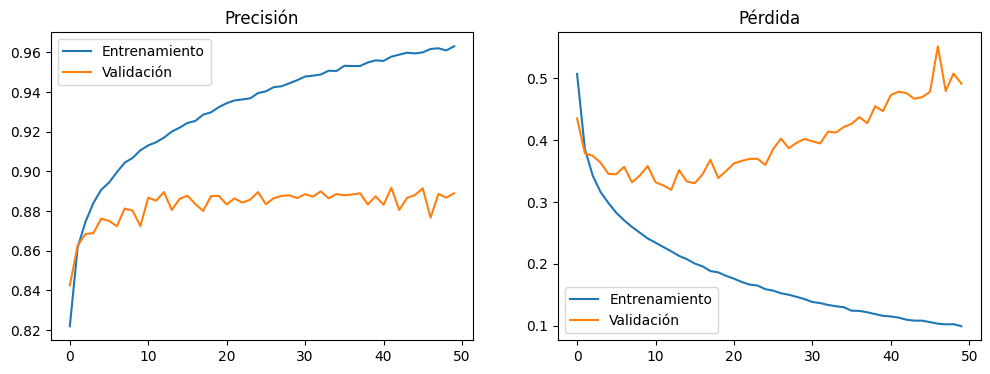

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


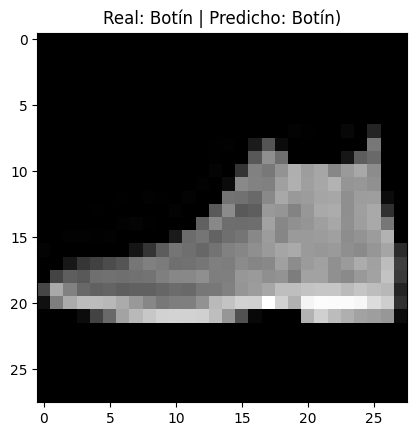

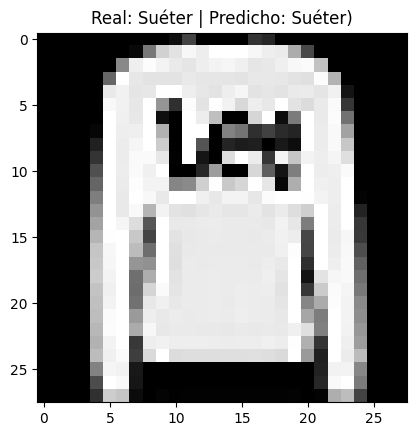

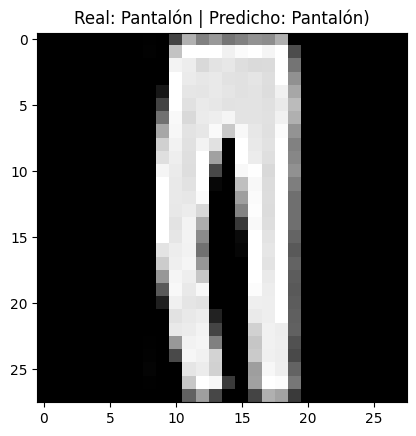

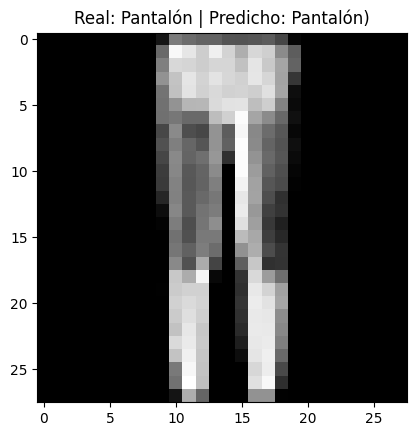

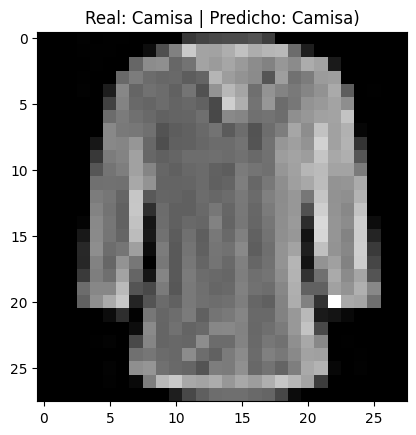

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset Fashion MNIST
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nombres de las clases (prendas)
nombres_clases = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

#  Exploración básica
print(f"Tamaño entrenamiento: {X_train.shape}")  # (60000, 28, 28)
print(f"Tamaño prueba: {X_test.shape}")          # (10000, 28, 28)

#  Preprocesamiento: normalizar valores de píxeles (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

#  Construir el modelo (red neuronal secuencial)
modelo = keras.Sequential([

    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# 5. Compilar el modelo
modelo.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# 6. Resumen de la arquitectura
modelo.summary()

# 7. Entrenar
historial = modelo.fit(X_train, y_train,
                       epochs=50,
                       validation_data=(X_test, y_test))

# 8. Evaluar en dato
test_loss, test_acc = modelo.evaluate(X_test, y_test, verbose=2)
print(f"\nPrecisión en prueba: {test_acc:.4f}")

# 9. Grafica evolución
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.legend()
plt.show()

# 10. Probar con algunas imágenes del test
predicciones = modelo.predict(X_test[:5])
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Real: {nombres_clases[y_test[i]]} | Predicho: {nombres_clases[np.argmax(predicciones[i])]})")
    plt.show()

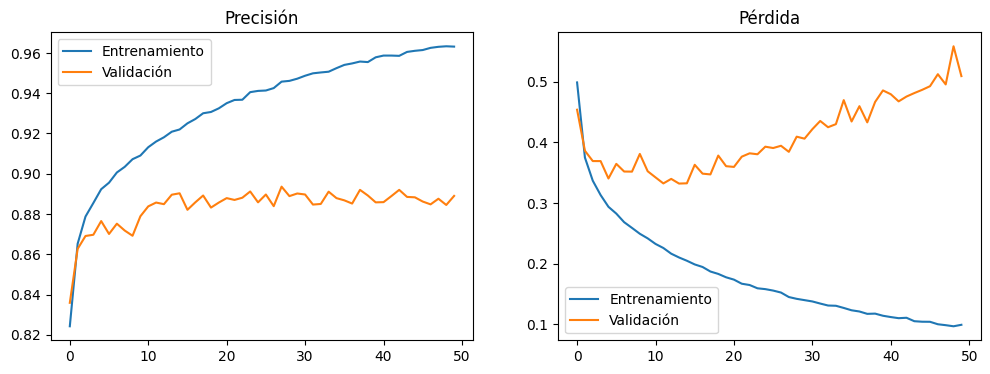

In [11]:

# 9. Grafica evolución
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(historial.history['accuracy'], label='Entrenamiento')
plt.plot(historial.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1,2,2)
plt.plot(historial.history['loss'], label='Entrenamiento')
plt.plot(historial.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.legend()
plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


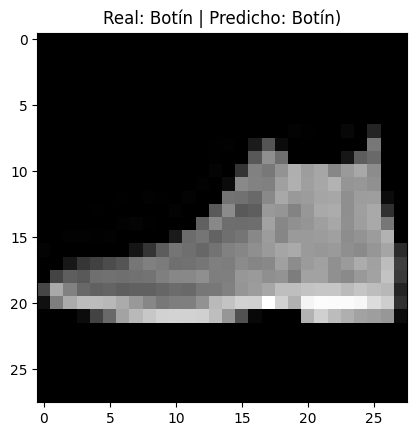

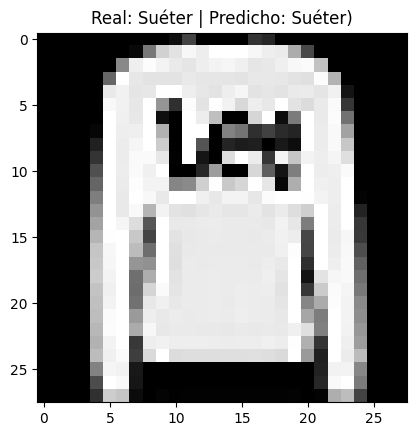

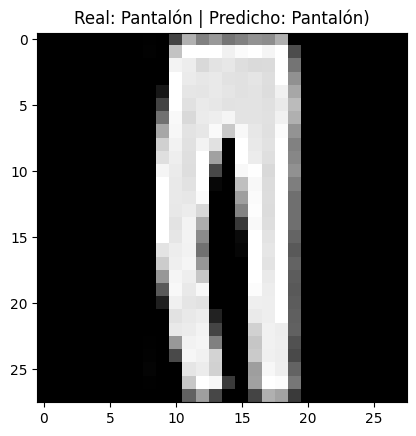

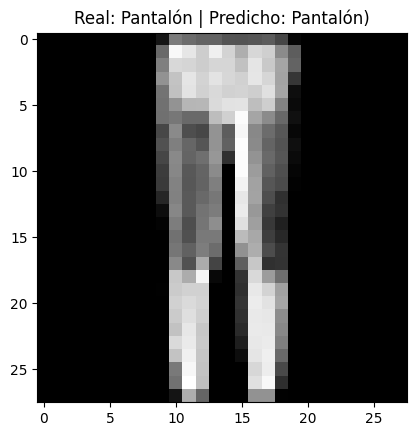

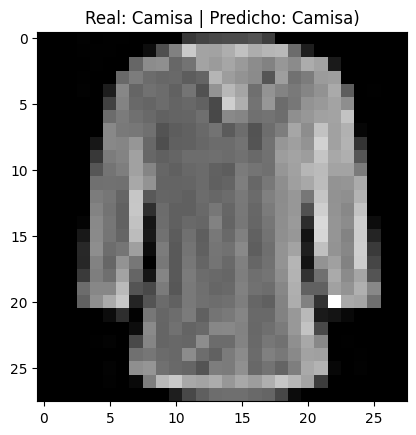

In [10]:
# 10. Probar con algunas imágenes del test
predicciones = modelo.predict(X_test[:5])
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Real: {nombres_clases[y_test[i]]} | Predicho: {nombres_clases[np.argmax(predicciones[i])]})")
    plt.show()